Device: cpu
Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train: 2800  Val: 600  Test: 600
Extracting features...


100%|██████████| 600/600 [02:30<00:00,  3.98it/s]


Feature shapes: Train: (2800, 768) Val: (600, 768) Test: (600, 768)

===== Training with PolyLoss =====
Epoch 1/50 - Train Loss: 2.6166  Val Loss: 2.5671
Epoch 2/50 - Train Loss: 2.6016  Val Loss: 2.5410
Epoch 3/50 - Train Loss: 2.5865  Val Loss: 2.5179
Epoch 4/50 - Train Loss: 2.5765  Val Loss: 2.4972
Epoch 5/50 - Train Loss: 2.5662  Val Loss: 2.4783
Epoch 6/50 - Train Loss: 2.5571  Val Loss: 2.4614
Epoch 7/50 - Train Loss: 2.5508  Val Loss: 2.4462
Epoch 8/50 - Train Loss: 2.5425  Val Loss: 2.4324
Epoch 9/50 - Train Loss: 2.5402  Val Loss: 2.4199
Epoch 10/50 - Train Loss: 2.5339  Val Loss: 2.4084
Epoch 11/50 - Train Loss: 2.5287  Val Loss: 2.3983
Epoch 12/50 - Train Loss: 2.5237  Val Loss: 2.3889
Epoch 13/50 - Train Loss: 2.5216  Val Loss: 2.3805
Epoch 14/50 - Train Loss: 2.5160  Val Loss: 2.3729
Epoch 15/50 - Train Loss: 2.5134  Val Loss: 2.3658
Epoch 16/50 - Train Loss: 2.5113  Val Loss: 2.3594
Epoch 17/50 - Train Loss: 2.5110  Val Loss: 2.3536
Epoch 18/50 - Train Loss: 2.5083  Val 

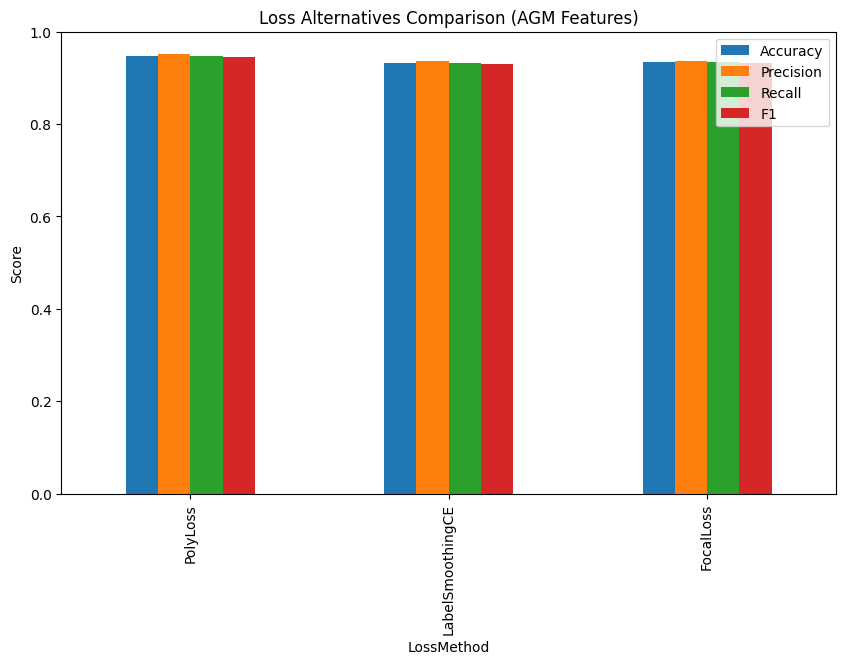

In [2]:
# =========================
# Imports & Device Setup
# =========================
import os, glob, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import pandas as pd

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\dataset"
IMG_SIZE = 224

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# =========================
# Minimal Transforms
# =========================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# Feature Extractor (Tiny Swin V2)
# =========================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features...")
X_train_feats = np.stack([extract_feature_from_path(p, train_transform) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])
print("Feature shapes: Train:", X_train_feats.shape, "Val:", X_val_feats.shape, "Test:", X_test_feats.shape)

# =========================
# Attention-Guided Mixup (AGM)
# =========================
def attention_guided_mixup(X, y, mixup_count, alpha=0.5):
    mixX, mixy = [], []
    n = len(X)
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        lam = np.random.beta(alpha, alpha)
        mixed = lam * X[i] + (1 - lam) * X[j]
        mixX.append(mixed)
        mixy.append(y[i])  # keep label of first
    return np.array(mixX), np.array(mixy)

mixup_count = len(X_train_feats) * 2
X_mix, y_mix = attention_guided_mixup(X_train_feats, y_train, mixup_count)
X_final, y_final = X_mix, y_mix

# =========================
# LoRA-adapted ViT Head
# =========================
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=4):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)
    def forward(self, x):
        return self.linear(x) + self.lora_b(self.lora_a(x))

class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, dropout_rate=0.4):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.head = LoRALinear(in_features, num_classes, r=4)
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(self.dropout(x)).squeeze(0)
        return self.head(self.dropout(x))

# =========================
# Loss Alternatives
# =========================
class PolyLoss(nn.Module):
    def __init__(self, epsilon=1.0, smoothing=0.1):
        super().__init__()
        self.epsilon = epsilon
        self.smoothing = smoothing
    def forward(self, logits, target):
        num_classes = logits.size(-1)
        with torch.no_grad():
            target_onehot = torch.zeros_like(logits).scatter_(1, target.unsqueeze(1), 1)
            target_onehot = target_onehot * (1 - self.smoothing) + self.smoothing / num_classes
        log_probs = torch.log_softmax(logits, dim=-1)
        ce_loss = -(target_onehot * log_probs).sum(dim=-1).mean()
        probs = torch.softmax(logits, dim=-1)
        pt = (target_onehot * probs).sum(dim=-1)
        poly_loss = ce_loss + self.epsilon * (1 - pt).mean()
        return poly_loss

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
    def forward(self, logits, target):
        num_classes = logits.size(-1)
        with torch.no_grad():
            target_onehot = torch.zeros_like(logits).scatter_(1, target.unsqueeze(1), 1)
            target_onehot = target_onehot * (1 - self.smoothing) + self.smoothing / num_classes
        log_probs = torch.log_softmax(logits, dim=-1)
        loss = -(target_onehot * log_probs).sum(dim=-1).mean()
        return loss

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25, smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.smoothing = smoothing
    def forward(self, logits, target):
        num_classes = logits.size(-1)
        with torch.no_grad():
            target_onehot = torch.zeros_like(logits).scatter_(1, target.unsqueeze(1), 1)
            if self.smoothing > 0:
                target_onehot = target_onehot * (1 - self.smoothing) + self.smoothing / num_classes
        probs = torch.softmax(logits, dim=-1)
        pt = (target_onehot * probs).sum(dim=-1)
        log_probs = torch.log(pt + 1e-12)
        loss = -self.alpha * (1 - pt) ** self.gamma * log_probs
        return loss.mean()

LOSS_METHODS = {
    "PolyLoss": PolyLoss(epsilon=0.6, smoothing=0.6),
    "LabelSmoothingCE": LabelSmoothingCrossEntropy(smoothing=0.1),
    "FocalLoss": FocalLoss(gamma=2.0, alpha=0.25, smoothing=0.1)
}

# =========================
# Dataloaders (Val & Test remain same for all losses)
# =========================
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                                      torch.tensor(y_val, dtype=torch.long)),
                        batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32),
                                       torch.tensor(y_test, dtype=torch.long)),
                         batch_size=64, shuffle=False)

# =========================
# Training & Evaluation
# =========================
results = []

for loss_name, criterion in LOSS_METHODS.items():
    print(f"\n===== Training with {loss_name} =====")

    # Reset model
    in_features = X_final.shape[1]
    num_classes = len(CLASS_NAMES)
    model_head = ViTHead(in_features, num_classes, dropout_rate=0.4).to(device)
    optimizer = torch.optim.Adam(model_head.parameters(), lr=1e-5, weight_decay=1e-4)

    train_loader = DataLoader(TensorDataset(torch.tensor(X_final, dtype=torch.float32),
                                            torch.tensor(y_final, dtype=torch.long)),
                              batch_size=64, shuffle=True)

    # Training Loop
    EPOCHS = 50
    PATIENCE = 5
    best_val_loss = float("inf")
    wait = 0
    best_model_path = f"{loss_name}_best.pth"

    for epoch in range(EPOCHS):
        model_head.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model_head(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        train_loss = total_loss / len(train_loader.dataset)

        # Validation
        model_head.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                loss = criterion(model_head(xb), yb)
                val_loss += loss.item() * xb.size(0)
        val_loss /= len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            torch.save(model_head.state_dict(), best_model_path)
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Evaluation
    model_head.load_state_dict(torch.load(best_model_path))
    model_head.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            preds = torch.argmax(model_head(xb), dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
    results.append([loss_name, acc, prec, rec, f1])
    print(f"[{loss_name}] Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

# =========================
# Results Table & Plot
# =========================
df_results = pd.DataFrame(results, columns=["LossMethod","Accuracy","Precision","Recall","F1"])
print("\nFinal Loss Comparison Table:")
print(df_results)

df_results.plot(x="LossMethod", y=["Accuracy","Precision","Recall","F1"], kind="bar", figsize=(10,6))
plt.title("Loss Alternatives Comparison (AGM Features)")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()